# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Вы предобработали данные в SQL, и теперь они готовы для проверки гипотезы в Python. Загрузите данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности из файла yandex_knigi_data.csv. Если работаете локально, скачать файл можно по ссылке.

Проверьте наличие дубликатов в идентификаторах пользователей. Сравните размеры групп, их статистики и распределение.

Напомним, как выглядит гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовьте аналитическую записку, в которой опишите:

Выбранный тип t-теста и уровень статистической значимости.

Результат теста, или p-value.

Вывод на основе полученного p-value, то есть интерпретацию результатов.

Одну или две возможные причины, объясняющие полученные результаты.

## Напишите заголовок первой части проекта здесь

Проверка гипотезы о разнице в активности пользователей сервиса Яндекс-Книги: Москва и Санкт-Петербург

- Автор: Artem Sokolskii
- Дата: 10.06.2026

## Цели и задачи проекта

<font color='#777778'>В этом блоке перечислите цель проекта и те задачи, которые вы решаете. Можно использовать описания проекта, но будет полезно, если вы сформулируете основную цель проекта самостоятельно.</font>

Цель проекта - статистически проверить, действительно ли пользователи из Санкт-Петербурга проводят в среднем больше времени, чем пользователи из Москвы

Задачи проекта:
- Загрузика и обработка данных
- Проверка данных на дубликаты и пропуски
- Установить размер выборки
- Выбрать подходящий статистический тест
- Сформулировать нулевую и альтернативную гипотезы
- Провести односторонний t-тест для двух независимых выборок
- Интерпретировать p-value и сделать вывод
- Сформулировать итоговый вывод

## Описание данных

<font color='#777778'>Здесь приведите описание данных.</font>

Файл: yandex_knigi_data.csv содержит данные о пользователях из Москвы и Санкт-Петербурга.

Основные поля:

- ser_id - уникальный идентификатор пользователя.
- city - город (Москва / Санкт-Петербург).
- total_hours - суммарное время активности в приложении (чтение + прослушивание) в часах.

## Содержимое проекта

<font color='#777778'>Перечислите основные шаги проекта или напишите оглавление. Используйте описание проекта, чтобы зафиксировать основные шаги.</font>

- Загрузка библиотек и данных
- Проверка дубликатов по user_id
- Размер и описательные статистики по группам
- Визуализация распределения
- Проверка предположений для t-теста
- Выбор типа t-теста
- Расчёт p-value
- Вывод и интерпретация
- Возможные причины различий

## 1. Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
# Импорт библиотеки pandas для работы с данными
import pandas as pd

# Импорт matplotlib для построения графиков
import matplotlib.pyplot as plt

# Импорт stats из scipy для статистических тестов
from scipy import stats

# Импорт seaborn для улучшенной визуализации
import seaborn as sns

In [2]:
# Данные содержат информацию о пользователях Москвы и Санкт-Петербурга
df = pd.read_csv('https://code.s3.yandex.net/datasets/yandex_knigi_data.csv')

# Вывод первых 5 строк для проверки структуры данных
df.head()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [3]:
# Вывод общей информации о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


In [4]:
# Удаляем столбец 'Unnamed: 0'
df = df.drop('Unnamed: 0', axis=1)

In [5]:
# Проверяем, есть ли пропуски
df.isna().sum()

city     0
puid     0
hours    0
dtype: int64

In [6]:
# Считаем количество пользователей в каждом городе
df['city'].value_counts()

Москва             6234
Санкт-Петербург    2550
Name: city, dtype: int64

In [7]:
# Проверка дубликатов пользователей
df['puid'].duplicated().sum()

244

In [8]:
# Удаляем дубликаты
df_clean = df.drop_duplicates(subset='puid', keep='first')

# Проверяем результат
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8540 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8540 non-null   object 
 1   puid    8540 non-null   int64  
 2   hours   8540 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 266.9+ KB


In [9]:
# Размер групп после очистки
df_clean['city'].value_counts()

Москва             6234
Санкт-Петербург    2306
Name: city, dtype: int64

In [10]:
# Группируем данные по городу и для столбца 'hours' считаем среднее, медиану, стандарное отклонение
df_clean.groupby('city')['hours'].agg(['mean', 'median', 'std'])

,mean,median,std
city,,,
Москва,10.881092,0.924498,36.851683
Санкт-Петербург,11.264433,0.875355,39.831755


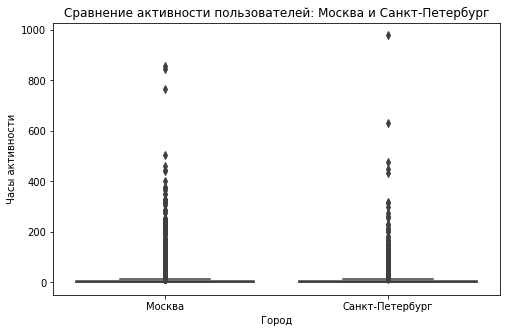

In [11]:
# Визуализация распределения данных
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='city', y='hours')
plt.title('Сравнение активности пользователей: Москва и Санкт-Петербург')
plt.xlabel('Город')
plt.ylabel('Часы активности')
plt.show()

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [12]:
# Только часы активности пользователей Москвы
msc = df_clean[df_clean['city'] == 'Москва']['hours']
# Только часы активности пользователей Санкт-Петербурга
spb = df_clean[df_clean['city'] == 'Санкт-Петербург']['hours']

# Задаём уровень статистической значимости
alpha = 0.05

In [13]:
# Проводим односторонний двухвыборочный t-тест
results = stats.ttest_ind(
    spb, 
    msc, 
    alternative='greater'
)

# Округляем p-value
p_value = round(results.pvalue, 2)

# Выводим результат на экран
print(f"Значение p-value = {p_value}")

Значение p-value = 0.34


In [14]:
# Сравниваем p-value с уровнем значимости alpha
if p_value > alpha:
    print("Принимаем нулевую гипотезу: значимой разницы нет")
else:
    print("Принимаем альтернативную гипотезу: активность в СПб статистически значимо выше")

Принимаем нулевую гипотезу: значимой разницы нет


## 3. Аналитическая записка
По результатам анализа данных подготовьте аналитическую записку, в которой опишете:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.



1. Тип теста и уровень значимости:
- односторонний двухвыборочный t-тест (независимые выборки, alternative = 'greater')
- уровень значимости: α = 0.05
2. Результат теста:
- p-value = 0.34
3. Вывод: 
- значение p-value больше чем уровень значимости, это значит что мы не можем отвергнуть нулевую гипотезу, а именно:
статистически значимых различий между средним временем активности пользователей из Санкт-Петербург и Москвы не обнаружено, гипотеза о том, что в Санкт-Петербурге читают больше чем в Москве не подтвердилась
4. Возможные причины:
- Огромный разброс в данных сильно варьируется, разница в средних невелика
- Сильная ассиметрия распределение - медианы данных примерно в 10 раз меньше средних показателей, данные распределены слишком вытянуто

# Часть 2. Анализ результатов A/B-тестирования

Теперь вам нужно проанализировать другие данные. Представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

## 1. Опишите цели исследования.



Цель проекта - статистически проверить, действительно ли новая версия сайта с измененным интерфейсом повысит количество пользователей, в отличии от тех, которые продолжат пользоваться старой версией.

**Сформулируем гипотезы:**

- Нулевая гипотеза H₀: Упрощение интерфейса не привело к увеличению показателя конверсии пользователей в покупаетелй.

- Альтернативная гипотеза H₁: Упрощение интерфейса приведёт к тому, что в течение семи дней после регистрации в системе конверсия зарегистрированных пользователей в покупателей увеличится как минимум на три процентных пункта.

**Задачи:**
- Загрузка и предобработка данных
- Формирование выборки для теста
- Определение горизонта анализа
- Оценка корректности теста
- Расчет метрик
- Статистический анализ
- Формулировка выводов и рекомендаций

## 2. Загрузите данные, оцените их целостность.


In [15]:
# Загрузка данных участников теста
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')

# Загрузка событий (архив zip)
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip', parse_dates=['event_dt'], low_memory=False)

In [16]:
# Выводим информацию о participants: колонки, типы, количество записей
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


In [17]:
# Выводим первые 5 строк для ознакомления с данными
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [18]:
# Выводим информацию о событиях
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


In [19]:
# Выводим первые 5 строк событий
events.head()

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [20]:
# Проверяем результат фильтрации
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


In [21]:
# Отбираем только участников теста interface_eu_test
test_participants = participants[participants['ab_test'] == 'interface_eu_test']

# Объединяем участников с их событиями (inner join)
df = test_participants.merge(events, how='inner')
df

,user_id,group,ab_test,device,event_dt,event_name,details
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31,registration,-2.38
1,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:49,login,NaN
2,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:57,login,NaN
3,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:38:54,login,NaN
4,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-08 22:15:35,login,NaN
...,...,...,...,...,...,...,...
79710,FFF28D02B1EACBE1,B,interface_eu_test,PC,2020-12-24 00:56:12,product_cart,NaN
79711,FFF28D02B1EACBE1,B,interface_eu_test,PC,2020-12-24 00:57:23,product_cart,NaN
79712,FFF58BC33966EB51,A,interface_eu_test,Android,2020-12-13 17:37:34,registration,-0.45
79713,FFF58BC33966EB51,A,interface_eu_test,Android,2020-12-13 17:56:02,login,NaN


In [22]:
# Проверяем количество событий каждого типа
df['event_name'].value_counts()

login           29617
product_page    18982
registration    10850
purchase        10225
product_cart    10041
Name: event_name, dtype: int64

In [23]:
pass

In [24]:
# Проверяем распределение пользователей по группам
df['group'].value_counts()

B    41194
A    38521
Name: group, dtype: int64

In [25]:
# Проверяем количество уникальных пользователей
df['user_id'].nunique()

10850

## 3. По таблице `ab_test_participants` оцените корректность проведения теста:

   3\.1 Выделите пользователей, участвующих в тесте, и проверьте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [26]:
# Получаем список уникальных пользователей теста
test_users = df['user_id'].unique()

# Находим пересечения: пользователи, которые также участвуют в recommender_system_test
inter_users = participants[(participants['user_id'].isin(test_users)) & 
                           (participants['ab_test'] == 'recommender_system_test')]
inter_users

,user_id,group,ab_test,device
1,001064FEAAB631A1,B,recommender_system_test,Android
9,00341D8401F0F665,A,recommender_system_test,iPhone
26,0082295A41A867B5,A,recommender_system_test,iPhone
41,00E68F103C66C1F7,A,recommender_system_test,PC
46,00EFA157F7B6E1C4,A,recommender_system_test,Android
...,...,...,...,...
14459,FEA0C585A53E7027,B,recommender_system_test,Android
14465,FEC0BCA6C323872F,A,recommender_system_test,PC
14490,FF2174A1AA0EAD20,A,recommender_system_test,Android
14496,FF44696E39039D29,A,recommender_system_test,Mac


In [27]:
# Извлекаем уникальных пользователей для исключения
exclude_users = inter_users['user_id'].unique()

# Исключаем этих пользователей из данных
df_clean = df[~df['user_id'].isin(exclude_users)]

df_clean.head()

,user_id,group,ab_test,device,event_dt,event_name,details
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31,registration,-2.38
1,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:49,login,NaN
2,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:57,login,NaN
3,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:38:54,login,NaN
4,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-08 22:15:35,login,NaN


In [28]:
# Проверяем результат: распределение по группам после очистки
df_clean['group'].value_counts()

B    38115
A    35700
Name: group, dtype: int64

In [29]:
# Создаём колонку, которая объединяет название теста и группу
participants['test_group'] = participants['ab_test'] + '_' + participants['group']
participants.head()

,user_id,group,ab_test,device,test_group
0,0002CE61FF2C4011,B,interface_eu_test,Mac,interface_eu_test_B
1,001064FEAAB631A1,B,recommender_system_test,Android,recommender_system_test_B
2,001064FEAAB631A1,A,interface_eu_test,Android,interface_eu_test_A
3,0010A1C096941592,A,recommender_system_test,Android,recommender_system_test_A
4,001E72F50D1C48FA,A,interface_eu_test,Mac,interface_eu_test_A


In [30]:
participants['test_group'].value_counts()

interface_eu_test_B          5467
interface_eu_test_A          5383
recommender_system_test_A    2747
recommender_system_test_B     928
Name: test_group, dtype: int64

In [31]:
# Проверим
delete = participants.groupby('user_id')['test_group'].nunique().sort_values(ascending = False)

In [32]:
del_users = delete[delete > 1]
del_users 

user_id
83AB3C13B3972BAE    2
E0EEE04D9FDB4931    2
6786C23A54D59DD4    2
21C2D41E1FDF1E70    2
21AEB217BA764EAB    2
                   ..
0082295A41A867B5    2
FFF28D02B1EACBE1    2
8A2FACABB19EDC70    2
06C6018D3CB3E903    2
00341D8401F0F665    2
Name: test_group, Length: 887, dtype: int64

In [33]:
clean_users = delete[delete == 1].index

clean_participants = participants[participants['user_id'].isin(clean_users)]
clean_participants = clean_participants[clean_participants['ab_test'] == 'interface_eu_test']

In [34]:
clean_participants.head()

,user_id,group,ab_test,device,test_group
0,0002CE61FF2C4011,B,interface_eu_test,Mac,interface_eu_test_B
4,001E72F50D1C48FA,A,interface_eu_test,Mac,interface_eu_test_A
5,002412F1EB3F6E38,B,interface_eu_test,Mac,interface_eu_test_B
6,002540BE89C930FB,B,interface_eu_test,Android,interface_eu_test_B
7,0031F1B5E9FBF708,A,interface_eu_test,Android,interface_eu_test_A


In [35]:
clean_participants['group'].value_counts()

B    5011
A    4952
Name: group, dtype: int64

In [36]:
e_clean = events[events['user_id'] != 'GLOBAL']

In [37]:
df_final = clean_participants.merge(e_clean, how = 'inner')
df_final

,user_id,group,ab_test,device,test_group,event_dt,event_name,details
0,0002CE61FF2C4011,B,interface_eu_test,Mac,interface_eu_test_B,2020-12-07 04:37:31,registration,-2.38
1,0002CE61FF2C4011,B,interface_eu_test,Mac,interface_eu_test_B,2020-12-07 04:37:49,login,NaN
2,0002CE61FF2C4011,B,interface_eu_test,Mac,interface_eu_test_B,2020-12-07 04:37:57,login,NaN
3,0002CE61FF2C4011,B,interface_eu_test,Mac,interface_eu_test_B,2020-12-07 04:38:54,login,NaN
4,0002CE61FF2C4011,B,interface_eu_test,Mac,interface_eu_test_B,2020-12-08 22:15:35,login,NaN
...,...,...,...,...,...,...,...,...
73810,FFEFC0E55C1CCD4F,A,interface_eu_test,PC,interface_eu_test_A,2020-12-13 23:52:22,login,NaN
73811,FFEFC0E55C1CCD4F,A,interface_eu_test,PC,interface_eu_test_A,2020-12-28 00:29:10,login,NaN
73812,FFF58BC33966EB51,A,interface_eu_test,Android,interface_eu_test_A,2020-12-13 17:37:34,registration,-0.45
73813,FFF58BC33966EB51,A,interface_eu_test,Android,interface_eu_test_A,2020-12-13 17:56:02,login,NaN


3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [38]:
# Проверяем количество регистраций и покупок в очищенных данных
df_final['event_name'].value_counts()

login           27360
product_page    17614
registration     9963
purchase         9487
product_cart     9391
Name: event_name, dtype: int64

In [39]:
# Создаем таблицу с датами регистрации каждого пользователя
registrations = df_final[df_final['event_name'] == 'registration'][['user_id', 'event_dt']]
registrations.columns = ['user_id', 'reg_date']

# Присоединяем дату регистрации к каждому событию
df_merged = df_final.merge(registrations, on='user_id', how='inner')

# Рассчитываем количество дней между событием и регистрацией
df_merged['time_diff'] = df_merged['event_dt'] - df_merged['reg_date']

In [40]:
# Оставляем только события, произошедшие в первые 7 дней
df_7days = df_merged[df_merged['time_diff'] <= pd.Timedelta(days=7)]
df_7days

,user_id,group,ab_test,device,test_group,event_dt,event_name,details,reg_date,time_diff
0,0002CE61FF2C4011,B,interface_eu_test,Mac,interface_eu_test_B,2020-12-07 04:37:31,registration,-2.38,2020-12-07 04:37:31,0 days 00:00:00
1,0002CE61FF2C4011,B,interface_eu_test,Mac,interface_eu_test_B,2020-12-07 04:37:49,login,NaN,2020-12-07 04:37:31,0 days 00:00:18
2,0002CE61FF2C4011,B,interface_eu_test,Mac,interface_eu_test_B,2020-12-07 04:37:57,login,NaN,2020-12-07 04:37:31,0 days 00:00:26
3,0002CE61FF2C4011,B,interface_eu_test,Mac,interface_eu_test_B,2020-12-07 04:38:54,login,NaN,2020-12-07 04:37:31,0 days 00:01:23
4,0002CE61FF2C4011,B,interface_eu_test,Mac,interface_eu_test_B,2020-12-08 22:15:35,login,NaN,2020-12-07 04:37:31,1 days 17:38:04
...,...,...,...,...,...,...,...,...,...,...
73809,FFEFC0E55C1CCD4F,A,interface_eu_test,PC,interface_eu_test_A,2020-12-13 23:52:15,registration,0.0,2020-12-13 23:52:15,0 days 00:00:00
73810,FFEFC0E55C1CCD4F,A,interface_eu_test,PC,interface_eu_test_A,2020-12-13 23:52:22,login,NaN,2020-12-13 23:52:15,0 days 00:00:07
73812,FFF58BC33966EB51,A,interface_eu_test,Android,interface_eu_test_A,2020-12-13 17:37:34,registration,-0.45,2020-12-13 17:37:34,0 days 00:00:00
73813,FFF58BC33966EB51,A,interface_eu_test,Android,interface_eu_test_A,2020-12-13 17:56:02,login,NaN,2020-12-13 17:37:34,0 days 00:18:28


Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [41]:
# Фактические показатели выборок
df_7days['group'].value_counts()

B    32541
A    31264
Name: group, dtype: int64

**По калькулятору Эвана-Миллера требуется 3692 пользователя в каждой группе**
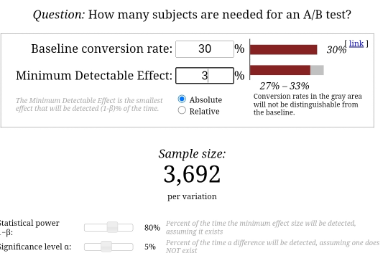

**Обе группы превышают минимальный требуемый размер выборки**

- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [42]:
# Размеры групп (количество зарегистрировавшихся)
A_size = 4952
B_size = 5011

In [43]:
# Отбираем пользователей группы A
A_users = df_7days[df_7days['group'] == 'A']
A_pur = A_users[A_users['event_name'] == 'purchase']
A = A_pur['user_id'].nunique()
A

1377

In [44]:
# Отбираем пользователей группы B
B_users = df_7days[df_7days['group'] == 'B']
B_pur = B_users[B_users['event_name'] == 'purchase']
B = B_pur['user_id'].nunique()
B

1480

- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

In [45]:
# Рассчитываем конверсию в процентах
A_conv = A / A_size
B_conv = B / B_size
print(f"Конверсия группы А = {A_conv}, Конверсия группы B = {B_conv}")
print(f"Разница в конверсиях = {B_conv - A_conv}")

Конверсия группы А = 0.27806946688206785, Конверсия группы B = 0.29535022949511075
Разница в конверсиях = 0.0172807626130429


**Предварительный вывод: Новый интерфейс показал увеличение конверсии на 1.73% (с 27.81% до 29.54%), однако целевое увеличение в 3% пока не достигнуто, требуется статистическая проверка значимости полученного различия.**

## 4. Проведите оценку результатов A/B-тестирования:

- Проверьте изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

In [46]:
# Импортируем
from statsmodels.stats.proportion import proportions_ztest

In [47]:
# Проводим двусторонний z-тест для пропорций
alpha = 0.05

stat_ztest, p_value_ztest = proportions_ztest(
    [B, A],
    [B_size, A_size],
    alternative = 'larger'
)

# Выводим полученное p-value
print(p_value_ztest)

# Интерпретируем результат
if p_value_ztest > alpha:
    print(f"p-value больше уровня значимости, нулевая гипотеза находит подтверждение")
else:
    print(f"Альтернативная гипотеза гипотеза находит подтверждение - есть статистически значимое увеличение конверсии.")

0.028262547212292124
Альтернативная гипотеза гипотеза находит подтверждение - есть статистически значимое увеличение конверсии.


- Опишите выводы по проведённой оценке результатов A/B-тестирования. Что можно сказать про результаты A/B-тестирования? Был ли достигнут ожидаемый эффект в изменении конверсии?

**Новый интерфейс показал статистически значимое увеличение конверсии на 1,73% (с 27,81% до 29,54%, p-value = 0,0283). Однако целевой эффект в +3% не достигнут**

**Текущую версию интерфейса не рекомендуется внедрять, так как эффект ниже целевого, следует доработать интерфейс для достижения роста в 3%.**